In [200]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.cloud import storage
import io

In [201]:
df = pd.read_csv('../processed.csv')
print(df.columns)
df.head()

Index(['campaign', 'year', 'page', 'platform', 'media_type', 'category_l0',
       'category_l1', 'category_l2', 'url', 'content', 'cost_nzd', 'views',
       'hours', 'engagement', 'description_json', 'duration_seconds'],
      dtype='object')


,campaign,year,page,platform,media_type,category_l0,category_l1,category_l2,url,content,cost_nzd,views,hours,engagement,description_json,duration_seconds
0,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/729678446160620/,@jacobkneepkens crosses the chalk 🤙,NaN,38409.0,64.3328,682.0,"{""play_by_play"": ""A male rugby player in a bla...",12.839229
1,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/850774540642042/,@nanaiseturo 💨,NaN,235384.0,544.8062,3800.0,"{""play_by_play"": ""A male rugby player wearing ...",14.279229
2,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1120082556960744/,a classic rugby training drill 🏉,NaN,274028.0,712.1043,3261.0,"{""play_by_play"": ""A group of male rugby player...",19.644082
3,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1191989952906685/,"a great kick, a great backdrop 🎨",NaN,281319.0,623.9321,4929.0,"{""play_by_play"": ""A male rugby player runs up ...",15.625215
4,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1728500341153571/,a skill and a half 🚀,NaN,438181.0,894.3045,9850.0,"{""play_by_play"": ""A male All Black player trac...",13.605215


### extract json

In [202]:
# json schema
# {
# "play_by_play": "",
# "content_theme": [""],
# "format_access": [""],
# "people": [""],
# "brands": [""],
# "event": [""],
# "tone": [""],
# "context": [""],
# "overall_team": [""],
# "audio_format": [""]
# }

In [203]:
import json

JSON_LIST_FIELDS = [
    "content_theme", "format_access", "people", "brands",
    "event", "tone", "context", "overall_team", "audio_format",
]


def _parse_json(text):
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return None
    try:
        return json.loads(text)
    except Exception:
        return None


json_dicts = df["description_json"].map(_parse_json)
df["description"] = json_dicts.map(
    lambda d: ((d or {}).get("play_by_play") or "").strip() or pd.NA
).astype("string")

# keep parsed dicts in scope for the encoding cell
json_by_idx = {idx: d for idx, d in zip(df.index, json_dicts) if d is not None}
print(f"parsed: {len(json_by_idx)} / {len(df)}")


parsed: 12105 / 12105


In [204]:
df = df[df['description'].notna()]

### encoding 

In [205]:
import json

JSON_LIST_FIELDS = [
    "content_theme", "format_access", "people", "brands",
    "event", "tone", "context", "overall_team", "audio_format",
]

# build per-field token-sets per row index for O(1) lookups
field_to_sets = {
    field: {idx: set(d.get(field, []) or []) for idx, d in json_by_idx.items()}
    for field in JSON_LIST_FIELDS
}

vocabulary = {
    field: {
        value
        for d in json_by_idx.values()
        for value in (d.get(field, []) or [])
    }
    for field in JSON_LIST_FIELDS
}

oh_columns = {
    f"json_{field}_{value}": pd.Series(
        [
            int(
                field_to_sets[field].get(idx) is not None
                and value in field_to_sets[field][idx]
            )
            for idx in df.index
        ],
        index=df.index,
        dtype="int8",
    )
    for field in JSON_LIST_FIELDS
    for value in sorted(vocabulary[field])
}

df = pd.concat([df, pd.DataFrame(oh_columns)], axis=1)

# raw JSON column no longer needed
df = df.drop(columns=["description_json"])


from collections import Counter

import regex

POST_TITLE_COLUMN = "content"
HASHTAG_PATTERN = regex.compile(r"(?<![\p{L}\p{N}_])#([\p{L}\p{N}_]+)")
MENTION_PATTERN = regex.compile(r"(?<![\p{L}\p{N}_@])@([\p{L}\p{N}_][\p{L}\p{N}_.]*)")
EMOJI_PATTERN = regex.compile(
    r"(?:\p{Regional_Indicator}{2}|[#*0-9]\uFE0F?\u20E3|"
    r"\p{Extended_Pictographic}(?:\uFE0F|\p{Emoji_Modifier})?"
    r"(?:\u200D\p{Extended_Pictographic}(?:\uFE0F|\p{Emoji_Modifier})?)*)"
)


def _multi_hot_encode(frame, token_lists, prefix, column_name, min_frequency):
    if min_frequency < 1:
        raise ValueError("min_frequency must be at least 1")

    old_columns = [column for column in frame.columns if column.startswith(f"{prefix}_")]
    if old_columns:
        frame.drop(columns=old_columns, inplace=True)

    unique_tokens = token_lists.map(lambda tokens: list(dict.fromkeys(tokens)))
    frequencies = Counter(token for tokens in unique_tokens for token in tokens)
    vocabulary = sorted(token for token, count in frequencies.items() if count >= min_frequency)

    new_columns = {
        f"{prefix}_count": token_lists.map(len).astype("int16"),
        **{
            column_name(token): unique_tokens.map(
                lambda tokens, value=token: int(value in tokens)
            ).astype("int8")
            for token in vocabulary
        },
    }
    frame = pd.concat([frame, pd.DataFrame(new_columns, index=frame.index)], axis=1)
    return frame


def hashtag_encode(frame, column=POST_TITLE_COLUMN, min_frequency=1):
    tokens = frame[column].fillna("").astype(str).map(
        lambda text: [tag.casefold() for tag in HASHTAG_PATTERN.findall(text)]
    )
    return _multi_hot_encode(
        frame, tokens, "hashtag", lambda tag: f"hashtag_{tag}", min_frequency
    )


def mention_encode(frame, column=POST_TITLE_COLUMN, min_frequency=1):
    tokens = frame[column].fillna("").astype(str).map(
        lambda text: [mention.rstrip(".").casefold() for mention in MENTION_PATTERN.findall(text)]
    )
    return _multi_hot_encode(
        frame, tokens, "mention", lambda mention: f"mention_{mention}", min_frequency
    )


def emoji_encode(frame, column=POST_TITLE_COLUMN, min_frequency=1):
    tokens = frame[column].fillna("").astype(str).map(EMOJI_PATTERN.findall)

    def emoji_column(value):
        codepoints = "_".join(f"{ord(char):x}" for char in value)
        return f"emoji_u{codepoints}"

    return _multi_hot_encode(frame, tokens, "emoji", emoji_column, min_frequency)


df = hashtag_encode(df)
df = mention_encode(df)
df = emoji_encode(df)
df.head()

,campaign,year,page,platform,media_type,category_l0,category_l1,category_l2,url,content,...,emoji_u1faf3_1f3fd,emoji_u1faf4_1f3fd,emoji_u1faf5,emoji_u1faf5_1f3fc,emoji_u1faf5_1f3fd,emoji_u1faf6,emoji_u1faf6_1f3fc,emoji_u1faf6_1f3fd,emoji_u1faf6_1f3fe,emoji_u1faf8
0,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/729678446160620/,@jacobkneepkens crosses the chalk 🤙,...,0,0,0,0,0,0,0,0,0,0
1,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/850774540642042/,@nanaiseturo 💨,...,0,0,0,0,0,0,0,0,0,0
2,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1120082556960744/,a classic rugby training drill 🏉,...,0,0,0,0,0,0,0,0,0,0
3,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1191989952906685/,"a great kick, a great backdrop 🎨",...,0,0,0,0,0,0,0,0,0,0
4,Organic | Website,2025,ABXV,FB,Short Video,No Hashtag,No Hashtag,No Hashtag,https://www.facebook.com/reel/1728500341153571/,a skill and a half 🚀,...,0,0,0,0,0,0,0,0,0,0


# NLP

### clustering descriptions

In [206]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

texts = df['description'].tolist()

# Semantic embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

X = embedder.encode(texts, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/379 [00:00<?, ?it/s]

Best k: 3
Best silhouette score: 0.06132595


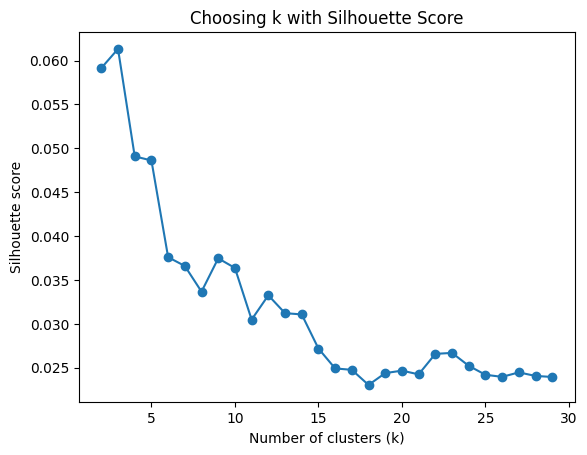

In [207]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_range = range(2, 30)

silhouette_scores = []

for k in k_range:
    clusterer = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    
    clusters = clusterer.fit_predict(X)
    
    score = silhouette_score(X, clusters)
    silhouette_scores.append(score)

# Find best k
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]

print("Best k:", best_k)
print("Best silhouette score:", max(silhouette_scores))

# Plot
plt.plot(k_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Choosing k with Silhouette Score")
plt.show()

[1 2 1 ... 1 1 1]


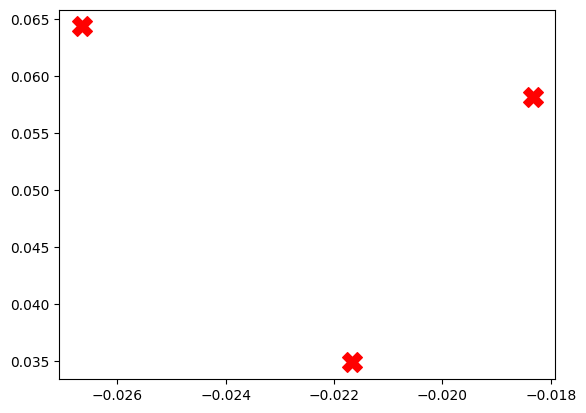

In [208]:
from sklearn.preprocessing import normalize

X_normalized = normalize(X)

clusterer = KMeans(
    # n_clusters=best_k,
    n_clusters=3,
    random_state=42,
    n_init="auto"
)

clusters = clusterer.fit_predict(X_normalized)
print(clusters)
df['description_cluster'] = clusters

centroids = clusterer.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')


### clustering title

In [209]:
# from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

texts = df['content'].tolist()

# Semantic embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

X = embedder.encode(texts, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/379 [00:00<?, ?it/s]

Best k: 12
Best silhouette score: 0.06871473


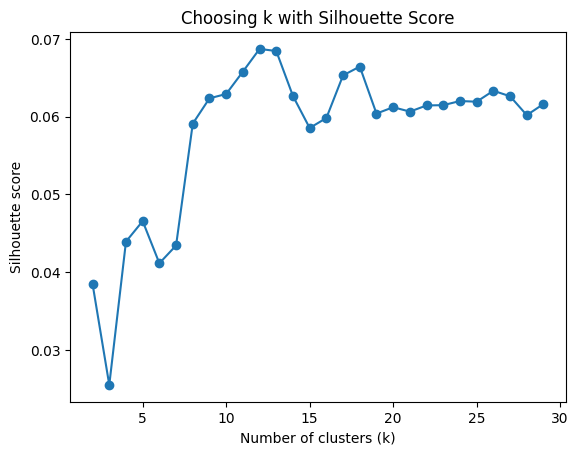

In [210]:

k_range = range(2, 30)

silhouette_scores = []

for k in k_range:
    clusterer = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    
    clusters = clusterer.fit_predict(X)
    
    score = silhouette_score(X, clusters)
    silhouette_scores.append(score)

# Find best k
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]

print("Best k:", best_k)
print("Best silhouette score:", max(silhouette_scores))

# Plot
plt.plot(k_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Choosing k with Silhouette Score")
plt.show()

[0 8 5 ... 3 3 3]


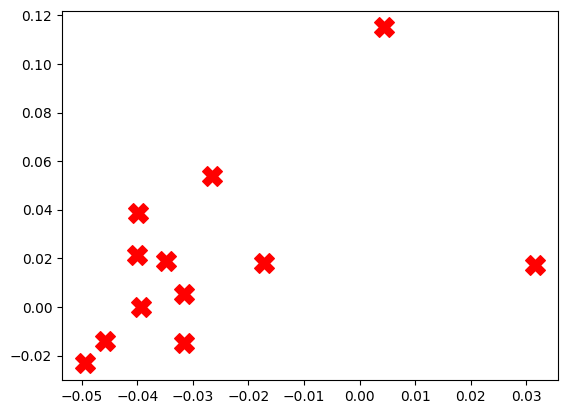

In [211]:
from sklearn.preprocessing import normalize

X_normalized = normalize(X)

clusterer = KMeans(
    # n_clusters=best_k,
    n_clusters=12,
    random_state=42,
    n_init="auto"
)

clusters = clusterer.fit_predict(X_normalized)
print(clusters)
df['title_cluster'] = clusters

centroids = clusterer.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')


### drop stuff

In [214]:
DROP = [
    'campaign',
    'page', 
    'platform',
    'media_type',
    "category_l0",
    "category_l1",
    "category_l2",
    "page",
    "platform",
    'url',
    'content',
    'hours',
    'description'
    'cost_nzd',
    'year'
]

df = df.drop(columns=DROP)

In [215]:
print(df.columns.tolist())

['views', 'engagement', 'duration_seconds', 'json_content_theme_celebration', 'json_content_theme_challenges', 'json_content_theme_conversion', 'json_content_theme_haka', 'json_content_theme_kick', 'json_content_theme_non rugby related', 'json_content_theme_player story', 'json_content_theme_rivalry', 'json_content_theme_rugby_skills', 'json_content_theme_run', 'json_content_theme_tackle', 'json_content_theme_training', 'json_content_theme_try', 'json_content_theme_undefined', 'json_format_access_announcement', 'json_format_access_archive', 'json_format_access_behind-the-scenes', 'json_format_access_candid clip', 'json_format_access_highlight', 'json_format_access_interview', 'json_format_access_montage', 'json_format_access_promotion', 'json_format_access_reaction', 'json_format_access_ticket sales', 'json_format_access_undefined', 'json_people_aaron cruden', 'json_people_aaron mauger', 'json_people_aaron reed', 'json_people_aaron smith', 'json_people_abigail paton', 'json_people_abig

In [216]:
Q1 = df['views'].quantile(0.25)
Q3 = df['views'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

0


<Axes: >

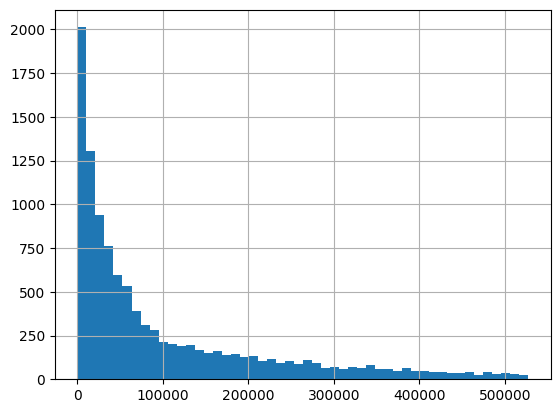

In [217]:
print(df['views'].isna().sum())
df = df[(df['views'] >= lower_bound) & (df['views'] <= upper_bound)]
df['views'].hist(bins=50)

0


<Axes: >

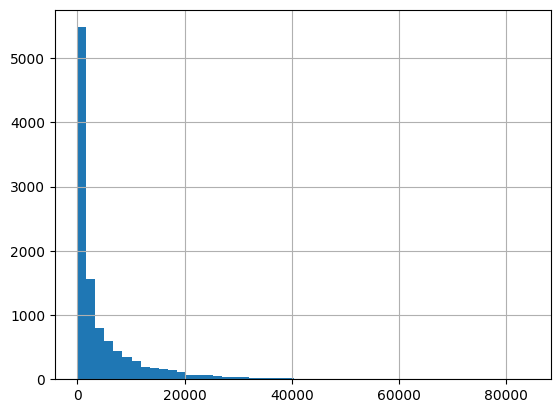

In [218]:
print(df['engagement'].isna().sum())
df = df[(df['engagement'] >= lower_bound) & (df['engagement'] <= upper_bound)]
df['engagement'].hist(bins=50)

## linreg views

In [220]:
DROP_COLS = ['views', 'engagement']

X = df.drop(columns=DROP_COLS)
y = np.log1p(df['views'])


In [221]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

8638 2160
8638 2160


Mean Squared Error (MSE): 18.0384
R-squared (R2) Score: -0.7856


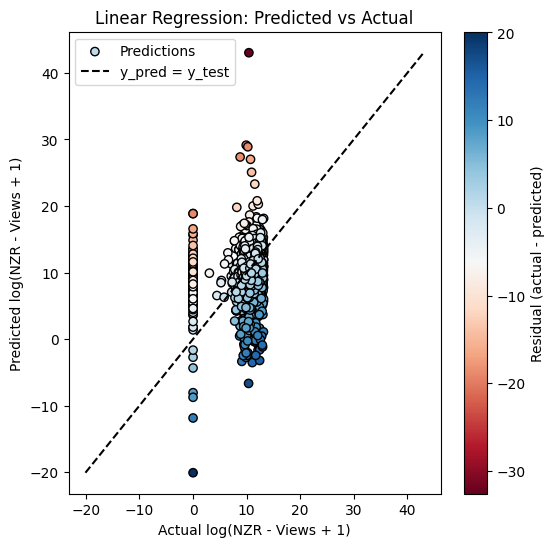

In [222]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score


model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# 7. Plot predicted vs actual with a y=x reference line.
y_test_array = np.asarray(y_test).ravel()
y_pred_array = np.asarray(y_pred).ravel()
residuals = y_test_array - y_pred_array
ref_min = float(min(y_test_array.min(), y_pred_array.min()))
ref_max = float(max(y_test_array.max(), y_pred_array.max()))

plt.figure(figsize=(6, 6))
scatter = plt.scatter(
    y_test_array, y_pred_array, c=residuals, cmap='RdBu',
    edgecolor='k', label='Predictions',
)
plt.plot([ref_min, ref_max], [ref_min, ref_max], 'k--', label='y_pred = y_test')
plt.xlabel('Actual log(NZR - Views + 1)')
plt.ylabel('Predicted log(NZR - Views + 1)')
plt.title('Linear Regression: Predicted vs Actual')
plt.colorbar(scatter, label='Residual (actual - predicted)')
plt.legend()
plt.show()

In [223]:
important_features = sorted(zip(model.coef_, X_train.columns))

print('top 5 negative:')
for t in important_features[:5]:
    print(t[0], t[1])

print('top 5 positive:')
for t in reversed(important_features[-5:]):
    print(t[0], t[1])


top 5 negative:
-24.10658624160015 json_people_sandra ioane
-22.426597847150305 json_people_casey caldwell
-20.702102186074704 hashtag_flashbackfriday
-19.671324210075504 json_brands_matatū
-19.491221889430587 json_people_noah hotham
top 5 positive:
27.127270057118164 json_people_will warbrick
26.136802853465543 json_people_aiden ross
26.032636588163175 hashtag_25
24.680678372816722 json_people_rhianna ferris
24.17022623621829 hashtag_mum


## linreg engagement

In [224]:
X = df.drop(columns=DROP_COLS)

y = np.log1p(df['engagement'])

In [225]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

8638 2160
8638 2160


Mean Squared Error (MSE): 9.0538
R-squared (R2) Score: -0.5662


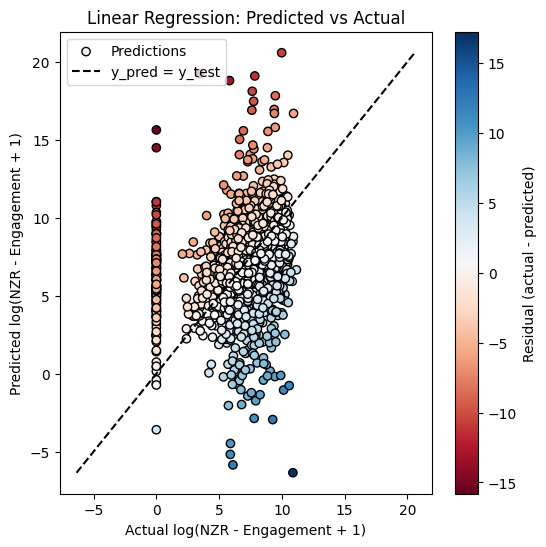

In [226]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

y_test_array = np.asarray(y_test).ravel()
y_pred_array = np.asarray(y_pred).ravel()
residuals = y_test_array - y_pred_array
ref_min = float(min(y_test_array.min(), y_pred_array.min()))
ref_max = float(max(y_test_array.max(), y_pred_array.max()))

plt.figure(figsize=(6, 6))
scatter = plt.scatter(
    y_test_array, y_pred_array, c=residuals, cmap='RdBu',
    edgecolor='k', label='Predictions',
)
plt.plot([ref_min, ref_max], [ref_min, ref_max], 'k--', label='y_pred = y_test')
plt.xlabel('Actual log(NZR - Engagement + 1)')
plt.ylabel('Predicted log(NZR - Engagement + 1)')
plt.title('Linear Regression: Predicted vs Actual')
plt.colorbar(scatter, label='Residual (actual - predicted)')
plt.legend()
plt.show()

In [228]:
important_features = sorted(zip(model.coef_, X_train.columns))

print('top 5 negative:')
for t in important_features[:5]:
    print(t[0], t[1])

print('top 5 positive:')
for t in reversed(important_features[-5:]):
    print(t[0], t[1])

top 5 negative:
-12.854964433397194 hashtag_bulls
-12.584495080516994 json_brands_newshub
-12.21453857451221 json_people_rhiarna ferris
-11.304302439746335 json_brands_energy super
-11.301668014660473 json_brands_chicago bulls
top 5 positive:
15.435047801288672 json_people_rachael rakatau
13.719082235935813 hashtag_superrugbyfantasy
12.916421124350794 emoji_u1f370
11.594011501588179 json_people_new zealand u85 team
10.90468053170868 hashtag_rugbyedit


### NN

In [359]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import RobustScaler

X = df.drop(columns=DROP_COLS)
# y = np.log1p(df[['engagement','views']])
y = np.log1p(df['engagement'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1
)

print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

# scaler = StandardScaler()
# scaler.fit(X_train)
# X_train_scaled = scaler.transform(X_train)
# X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)

9718 1080
9718 1080
(9718, 6322)


In [360]:
from keras import Input
from keras import Sequential, layers

model = Sequential()
model.add(Input(shape=(X.shape[1],)))


model.add(layers.Dense(1080, activation='relu'))
model.add(layers.Dropout(rate=0.3)) 
model.add(layers.Dense(540, activation='relu'))
model.add(layers.Dropout(rate=0.3)) 
model.add(layers.Dense(270, activation='relu'))
model.add(layers.Dropout(rate=0.3)) 
model.add(layers.Dense(135, activation='relu'))
model.add(layers.Dropout(rate=0.3))
model.add(layers.Dense(67, activation='relu'))
model.add(layers.Dropout(rate=0.3))
model.add(layers.Dense(33, activation='relu'))
model.add(layers.Dropout(rate=0.3))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dropout(rate=0.3))
model.add(layers.Dense(8, activation='relu'))
model.add(layers.Dropout(rate=0.3))
model.add(layers.Dense(4, activation='relu'))
model.add(layers.Dropout(rate=0.3))

# model.add(layers.Dense(2, activation='linear'))
model.add(layers.Dense(1, activation='linear'))


model.compile(loss='mse', optimizer='adam', metrics=['mae'])
model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_169 (Dense)               │ (None, 1080)           │     6,828,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_120 (Dropout)           │ (None, 1080)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_170 (Dense)               │ (None, 540)            │       583,740 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_121 (Dropout)           │ (None, 540)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_171 (Dense)               │ (None, 270)            │       146,070 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_122 (Dropout)           │ (None, 270)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_172 (Dense)               │ (None, 135)            │        36,585 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_123 (Dropout)           │ (None, 135)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_173 (Dense)               │ (None, 67)             │         9,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_124 (Dropout)           │ (None, 67)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_174 (Dense)               │ (None, 33)             │         2,244 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_125 (Dropout)           │ (None, 33)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_175 (Dense)               │ (None, 16)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_126 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_176 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_127 (Dropout)           │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_177 (Dense)               │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_128 (Dropout)           │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_178 (Dense)               │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,607,312 (29.02 MB)

 Trainable params: 7,607,312 (29.02 MB)

 Non-trainable params: 0 (0.00 B)

In [361]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

es = EarlyStopping(patience=20, restore_best_weights=True, monitor='val_loss' )
rop = ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')

history = model.fit(X_train, y_train, batch_size=32, epochs=1000, validation_split=0.2, callbacks=[es, rop])

Epoch 1/1000
243/243 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 38.1148 - mae: 5.3137 - val_loss: 26.6520 - val_mae: 4.8971 - learning_rate: 0.0010
Epoch 2/1000
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 27.8626 - mae: 4.4798 - val_loss: 24.2814 - val_mae: 4.6705 - learning_rate: 0.0010
Epoch 3/1000
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 22.8806 - mae: 3.9689 - val_loss: 17.4232 - val_mae: 3.9325 - learning_rate: 0.0010
Epoch 4/1000
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 20.8017 - mae: 3.7285 - val_loss: 13.7982 - val_mae: 3.4572 - learning_rate: 0.0010
Epoch 5/1000
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 19.5184 - mae: 3.5540 - val_loss: 11.7110 - val_mae: 3.1419 - learning_rate: 0.0010
Epoch 6/1000
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 17.7380 - mae: 3.3402 - val_loss: 10.5696 - val_mae: 2.9565 - learning_rate: 0.0010
Epoch 7/1000
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 16.6929 - mae: 3.2150 - val_loss: 10.6707 - val_mae: 2.

(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'Loss'}, xlabel='Epochs', ylabel='Loss'>,
        <Axes: title={'center': 'MAE'}, xlabel='Epochs', ylabel='MAE'>,
        <Axes: title={'center': 'Learning rate'}, xlabel='Epochs', ylabel='Learning rate'>],
       dtype=object))

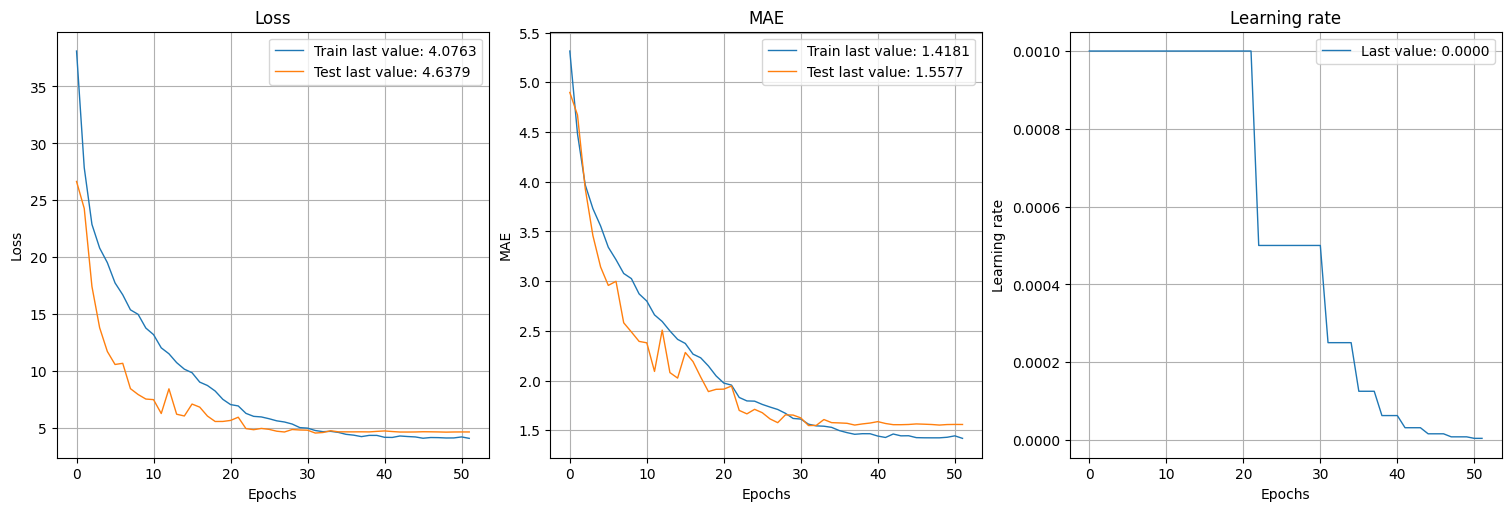

In [362]:
from plot_keras_history import plot_history

plot_history(history)

In [363]:
results = model.evaluate(X_test, y_test)

print(f"Test Loss: {results[0]}")
print(f"Test MAE: {results[1]}")

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.5867 - mae: 1.5665 
Test Loss: 4.58669376373291
Test MAE: 1.566482663154602


In [364]:
# Test Loss: 5.3443989753723145
# Test MAE: 1.5442880392074585

dummy_views = 10_000
error_range = np.exp(results[1])
low = dummy_views / error_range
high = dummy_views * error_range
print(error_range)
print(round(low,-3),'<--',dummy_views, '-->',round(high, -3))

baseline_mean = y_train.mean()
baseline_preds = abs(y_test - baseline_mean)
print('baseline mae', baseline_preds.mean())
print('model mae', results[1])

4.789771291255485
2000.0 <-- 10000 --> 48000.0
baseline mae 1.736747357960945
model mae 1.566482663154602
